## 1. Programa BEM en 3D

# 3D Frequency-Domain Boundary Element Method (BEM)

This tutorial demonstrates the implementation of a 3D Boundary Element Method (BEM) to analyze the interaction between regular linear water waves and submerged porous structures.

The formulation is based on:
- Linear potential flow theory
- Time-harmonic (frequency-domain) analysis
- Boundary integral equation formulation

The objective is to compute:
- Wave transmission and reflection

In [1]:
# 1. Automatic reloading of your .py files
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath(".."))    

import meshio
import numpy as np

from ADD_FUNCTIONS.PROCESS_MESH import PROCESS_MESH
from ADD_FUNCTIONS.COORDINATES import COORDINATES
from ADD_FUNCTIONS.ELEMENT_CONNECTION import ELEMENT_CONNECTION
from ADD_FUNCTIONS.COS_DIR import COS_DIR
from ADD_FUNCTIONS.MATCHING import MATCHING

from MATRICES.FUNDA6 import FUNDA6
from MATRICES.FUNDA6_TRI import FUNDA6_TRI
from MATRICES.GHMAT6 import GHMAT6
from MATRICES.ETAXJA import ETAXJA
from MATRICES.LOCIN6 import LOCIN6
from MATRICES.EXTIN6 import EXTIN6
from MATRICES.TRILOC6 import TRILOC6

from ADD_FUNCTIONS.POROUS_NODES import POROUS_NODES

from BOUNDARY_CONDITIONS.BC_FREE_SURFACE import BC_FREE_SURFACE
from BOUNDARY_CONDITIONS.BC_FAR_FIELD import BC_FAR_FIELD
from BOUNDARY_CONDITIONS.BC_INTERFACE import BC_INTERFACE
from BOUNDARY_CONDITIONS.BC_SCATTERING import BC_SCATTERING

from ADD_FUNCTIONS.FX_FUNCTION import FX_FUNCTION
from ADD_FUNCTIONS.ENERGY_FLUX import ENERGY_FLUX
from ADD_FUNCTIONS.NODES_FS import NODES_FS

from ADD_FUNCTIONS.VISUAL_FREE_SURFACE import VISUAL_FREE_SURFACE

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # activates 3D plotting

In [2]:
# Variables of interest

# Water depth
DEPTH         = 0.40;

RADIUS        = 0.36;
WIDTH_CHANNEL = 0.40*DEPTH;

NUM_OF_REG = 3;

gravity = 9.8056
rho     = 999.1033

In [3]:
# NUMBER OF FREQUENCIES
ttmax = 25

# WAVE PERIODS
kh = np.linspace(0.005, 3.00, ttmax)

# WAVE HEIGHT TO WAVELENGTH RATIO H/lambda
HL = 0.01

In [4]:
# Process the outer region
MESH_0_POS, MESH_0_QUADS9 = PROCESS_MESH("DOMAIN_0.msh")
MESH_1_POS, MESH_1_QUADS9 = PROCESS_MESH("DOMAIN_1.msh")
MESH_2_POS, MESH_2_QUADS9 = PROCESS_MESH("DOMAIN_2.msh")

In [5]:
# Number of nodes per quad element
NCONEC = 9;

In [6]:
# PRE-ASSIGN
N  = [0] * NUM_OF_REG
NE = [0] * NUM_OF_REG

In [7]:
N[0] ,  NE[0] ,  KCONEC0 = COORDINATES(MESH_0_POS , MESH_0_QUADS9)
N[1] ,  NE[1] ,  KCONEC1 = COORDINATES(MESH_1_POS , MESH_1_QUADS9)
N[2] ,  NE[2] ,  KCONEC2 = COORDINATES(MESH_2_POS , MESH_2_QUADS9)

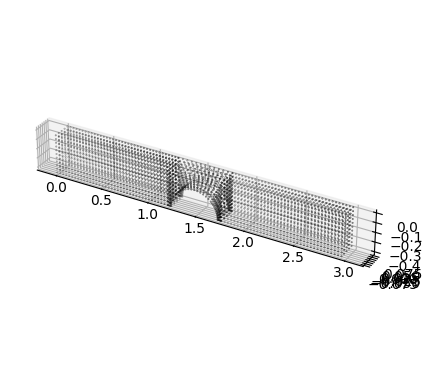

In [8]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    MESH_0_POS[:,0],
    MESH_0_POS[:,1],
    MESH_0_POS[:,2],
    c='k',
    s=0.1
)

ax.scatter(
    MESH_1_POS[:,0],
    MESH_1_POS[:,1],
    MESH_1_POS[:,2],
    c='k',
    s=0.1
)

ax.scatter(
    MESH_2_POS[:,0],
    MESH_2_POS[:,1],
    MESH_2_POS[:,2],
    c='k',
    s=0.1
)

#ax.grid(True)
ax.set_box_aspect([7.5,0.5,1])  # axis equal

plt.show()

In [9]:
# ELEMENT CONNECTION
REF_R0 , NORMAL0 = ELEMENT_CONNECTION(NCONEC , KCONEC0 , MESH_0_POS , NE[0])
REF_R1 , NORMAL1 = ELEMENT_CONNECTION(NCONEC , KCONEC1 , MESH_1_POS , NE[1])
REF_R2 , NORMAL2 = ELEMENT_CONNECTION(NCONEC , KCONEC2 , MESH_2_POS , NE[2])

In [10]:
# MATCHING NODES BETWEEN TWO ADJACENT REGIONS (INTERFACE)
NODES_MATCH_R0_R1 = MATCHING(REF_R0['OUT'] ,  MESH_0_POS  ,  KCONEC0  ,  REF_R1['IN'] ,  MESH_1_POS  ,  KCONEC1);
NODES_MATCH_R1_R2 = MATCHING(REF_R1['OUT'] ,  MESH_1_POS  ,  KCONEC1  ,  REF_R2['IN'] ,  MESH_2_POS  ,  KCONEC2);

In [11]:
N_total = N[0] + N[1] + N[2]

In [12]:
KCON_N_0  = KCONEC0[0:9, :]
KCON_N_01 = KCONEC1[0:9, :] + N[0]
KCON_N_02 = KCONEC2[0:9, :] + N[0] + N[1]

KCONEC = np.hstack((KCON_N_0, KCON_N_01, KCON_N_02))

In [13]:
# FORM SYSTEM OF EQUATIONS FOR EACH REGION
H0 , G0 = GHMAT6(MESH_0_POS , NCONEC , KCONEC0 , NE[0] , N[0] , DEPTH);
H1 , G1 = GHMAT6(MESH_1_POS , NCONEC , KCONEC1 , NE[1] , N[1] , DEPTH);
H2 , G2 = GHMAT6(MESH_2_POS , NCONEC , KCONEC2 , NE[2] , N[2] , DEPTH);

In [14]:
# MERGE H AND G MATRICES
from scipy.linalg import block_diag
H = np.zeros((N_total, N_total), dtype=np.complex128)

H = block_diag(H0, H1, H2)

NE_total = NE[0] + NE[1] + NE[2]

G = np.zeros((N_total, NCONEC * NE_total), dtype=np.complex128)

G = block_diag(G0, G1, G2)

In [15]:
# READ THE POROUS NODES IN BOTH REGIONS
[STORE_NODE_R0_out, STORE_NODE_R1_in] = POROUS_NODES(NCONEC, KCONEC0, KCONEC1, MESH_0_POS, MESH_1_POS, NODES_MATCH_R0_R1);
[STORE_NODE_R1_out, STORE_NODE_R2_in] = POROUS_NODES(NCONEC, KCONEC1, KCONEC2, MESH_1_POS, MESH_2_POS, NODES_MATCH_R1_R2);

In [16]:
# FREQUENCY ITERATIONS

# Preallocate if not already done
X_axis = np.zeros(ttmax)

CR = np.zeros(ttmax)
CT = np.zeros(ttmax)
KR = np.zeros(ttmax)
KT = np.zeros(ttmax)
KL = np.zeros(ttmax)

WAVE = {
    "k": np.zeros(ttmax),
    "lambda": np.zeros(ttmax),
    "HL": np.zeros(ttmax),
    "T": np.zeros(ttmax),
    "omega": np.zeros(ttmax),
    "Amp": np.zeros(ttmax)
}

# ============================
# MAIN LOOP
# ============================

for tt in range(ttmax):

    print(tt + 1)

    X_axis[tt] = kh[tt]

    # WAVE NUMBER
    k = kh[tt] / DEPTH

    # WAVE PERIOD
    T = np.sqrt((2*np.pi)**2 / (k * gravity * np.tanh(k * DEPTH)))

    # WAVE FREQUENCY
    f = 1.0 / T

    # ANGULAR FREQUENCY
    omega = 2*np.pi*f

    Wave_height = HL * (2*np.pi / k)
    Amp = Wave_height / 2

    # Store wave properties
    WAVE["k"][tt] = k
    WAVE["lambda"][tt] = 2*np.pi / k
    WAVE["HL"][tt] = Wave_height / (2*np.pi / k)
    WAVE["T"][tt] = T
    WAVE["omega"][tt] = omega
    WAVE["Amp"][tt] = Amp

    # SAVE MATRICES
    A = H.copy()
    B = G.copy()

    # ------------------------
    # BOUNDARY CONDITIONS
    # ------------------------
    # FREE SURFACE BC
    A = BC_FREE_SURFACE(A, B, omega, gravity, NCONEC, REF_R0["FS"], KCONEC, NE, 0)
    A = BC_FREE_SURFACE(A, B, omega, gravity, NCONEC, REF_R1["FS"], KCONEC, NE, 1)
    A = BC_FREE_SURFACE(A, B, omega, gravity, NCONEC, REF_R2["FS"], KCONEC, NE, 2)

    # FAR FIELD BC
    A = BC_FAR_FIELD(A, B, k, NCONEC,REF_R0["IN"],  KCONEC, NE, 0)
    A = BC_FAR_FIELD(A, B, k, NCONEC,REF_R2["OUT"], KCONEC, NE, 2)

    # INTERFACE
    A, B = BC_INTERFACE(A, B, NCONEC, STORE_NODE_R0_out, STORE_NODE_R1_in, N, NE, 0, 1)
    A, B = BC_INTERFACE(A, B, NCONEC, STORE_NODE_R1_out, STORE_NODE_R2_in, N, NE, 1, 2)

    # SCATTERING BC (from incident velocity potential in the left far field)
    BC_S = BC_SCATTERING(Wave_height, k, omega, gravity, DEPTH, MESH_0_POS, NCONEC, REF_R0["IN"], KCONEC, N, NE, 0)

    # RHS VECTOR
    FX_S = FX_FUNCTION(NCONEC, B, BC_S, N, NE)

    # SOLVE SYSTEM
    Coef_S = np.linalg.solve(A, FX_S)

    # ENERGY FLUX    
    FI = (WIDTH_CHANNEL) * (1/8) * rho * gravity * (Wave_height**2) * (omega / k) * (
        0.5 * (1 + (2 * k * DEPTH) / np.sinh(2 * k * DEPTH))
     )

    FLUX_REFLE, FLUX_TRANS = ENERGY_FLUX(Coef_S, omega, rho, k, gravity, Wave_height, DEPTH, NCONEC,
        REF_R0["IN"],  MESH_0_POS,
        REF_R2["OUT"], MESH_2_POS,
        KCONEC,
        N, NE, 0, 2)

    CR[tt] = np.sqrt(FLUX_REFLE / FI)
    CT[tt] = np.sqrt(FLUX_TRANS / FI)

    KR[tt] = FLUX_REFLE / FI
    KT[tt] = FLUX_TRANS / FI
    KL[tt] = 1.0 - KR[tt] - KT[tt]        

# END LOOPS

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25


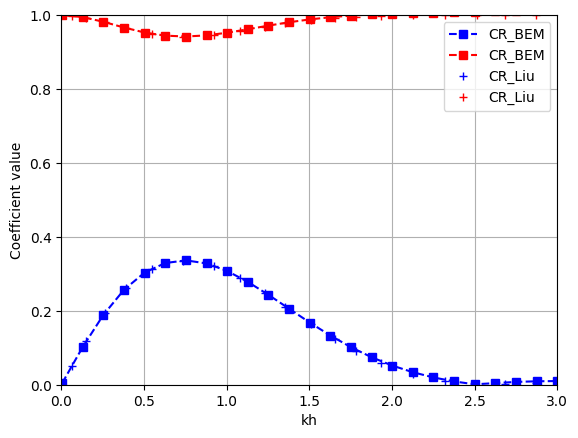

In [17]:
# Bragg reflection of water waves by multiple submerged semi-circular breakwaters - Yong Liu, Hua-jun Li, Lei Zhu
kh_Liu = np.array([
0.064, 0.152, 0.263, 0.391, 0.546,
0.734, 0.925, 1.083, 1.234, 1.356,
1.511, 1.654, 1.780, 1.934, 2.126,
2.321, 2.512, 2.685, 2.869
])

CR_Liu = np.array([
0.051, 0.118, 0.194, 0.262, 0.314,
0.336, 0.320, 0.288, 0.247, 0.210,
0.163, 0.123, 0.092, 0.060, 0.030,
0.009, -0.004, 0.003, 0.006
])

CT_Liu = np.sqrt(1 - CR_Liu**2)

plt.figure(15)

# plot(kh, KT, 'bs')
# 'bs' stands for blue squares
plt.plot(kh, CR, 'b--s', label='CR_BEM')
plt.plot(kh, CT, 'r--s', label='CR_BEM')

plt.plot(kh_Liu, CR_Liu, 'b+', label='CR_Liu')
plt.plot(kh_Liu, CT_Liu, 'r+', label='CR_Liu')

plt.xlim([0, 3.00])
plt.ylim([0, 1.00])

plt.xlabel('kh')
plt.ylabel('Coefficient value')

plt.legend()
plt.grid(True)

plt.savefig("CR_CT.pdf")

# Optional: display the plot
plt.show()